# Create alcohol consuption map
working with csv alcohol_extracted_sorted

In [3]:
import matplotlib; print(matplotlib.__version__)

3.10.9


In [4]:
import matplotlib; print(matplotlib.__version__)

3.10.9


In [5]:
import sys; print(sys.executable)

c:\Users\ThinkPad\miniconda3\python.exe


In [6]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import plotly.express as px

In [7]:
# load CSV
df = pd.read_csv(r"C:\Users\ThinkPad\Desktop\Mastermind\WHO_health_indicators\CSV_files\alcohol_extracted_sorted.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              4324 non-null   int64  
 1   Country_M49_code  4324 non-null   int64  
 2   Country           4324 non-null   str    
 3   Liters_of_alc     4324 non-null   float64
 4   lower_CI          4324 non-null   float64
 5   upper_CI          4324 non-null   float64
dtypes: float64(3), int64(2), str(1)
memory usage: 202.8 KB


In [8]:
# using claude

import plotly.express as px

fig = px.choropleth(df, 
    locations="Country_M49_code",
    color="Liters_of_alc")

In [9]:
print(df["Country_M49_code"].unique())

[  4   8  12  20  24  28  32  51  36  40  31  44  48  50  52 112  56  84
 204  64  68  70  72  76  96 100 854 108 132 116 120 124 140 148 152 156
 170 174 178 188 191 192 196 203 384 408 180 208 262 212 214 218 818 222
 226 232 233 748 231 242 246 250 266 270 268 276 288 300 308 320 324 624
 328 332 340 348 352 356 360 364 368 372 376 380 388 392 400 398 404 296
 414 417 418 428 422 426 430 434 440 442 450 454 458 462 466 470 478 480
 484 583 496 499 504 508 104 516 520 524 528 554 558 562 566 570 807 578
 512 586 591 598 600 604 608 616 620 634 410 498 642 643 646 659 662 670
 882 678 686 688 690 694 702 703 705  90 706 710 728 724 144 729 740 752
 756 760 762 764 626 768 776 780 788 795 798 792 800 804 784 826 834 840
 858 860 548 862 704 887 894 716]


In [11]:
import country_converter as cc

df["iso_alpha3"] = cc.convert(df["Country_M49_code"], src="UNcode", to="ISO3")

In [12]:
# check failed conversions
print(df[df["iso_alpha3"] == "not found"]["Country"].unique())

<StringArray>
[]
Length: 0, dtype: str


In [13]:
import plotly.express as px

df_2022 = df[df["Year"] == 2022]

fig = px.scatter_geo(
    df_2022,
    locations="iso_alpha3",
    size="Liters_of_alc",
    scope="europe",
    color="Liters_of_alc",
    color_continuous_scale="Reds",
    hover_name="Country",
    title="Alcohol Consumption per Capita in Europe (2022)",
    labels={"Liters_of_alc": "Litres of Alcohol"}
)

# Plotly's own save method (PNG)
fig.write_image(
    r'C:\Users\ThinkPad\Desktop\Mastermind\WHO_health_indicators\Plot_pictures\Alcohol_consumption_europe_map_2022_Version01.png',
    width=1200, height=800, scale=2
)

fig.show()


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              4324 non-null   int64  
 1   Country_M49_code  4324 non-null   int64  
 2   Country           4324 non-null   str    
 3   Liters_of_alc     4324 non-null   float64
 4   lower_CI          4324 non-null   float64
 5   upper_CI          4324 non-null   float64
 6   iso_alpha3        4324 non-null   str    
dtypes: float64(3), int64(2), str(2)
memory usage: 236.6 KB


In [15]:
#creating a europe only df_europe

europe_m49 = {
    # Northern Europe (154)
    208, 233, 246, 352, 372, 428, 440, 578, 752, 826,
    234, 831, 833, 832, 744, 248,
    # Eastern Europe (151)
    112, 100, 203, 348, 616, 498, 642, 643, 703, 804,
    # Southern Europe (039)
    8, 20, 70, 191, 292, 300, 336, 380, 470, 499,
    807, 620, 674, 688, 705, 724,
    # Western Europe (155)
    40, 56, 250, 276, 438, 442, 492, 528, 756,
}

df_europe = df[df['Country_M49_code'].isin(europe_m49)].reset_index(drop=True)

In [16]:
print(df_europe.shape)
print(df_europe['Country'].nunique(), 'countries')
print(sorted(df_europe['Country'].unique()))

(920, 7)
40 countries
['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Montenegro', 'Netherlands (Kingdom of the)', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Republic of Moldova', 'Romania', 'Russian Federation', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Ukraine', 'United Kingdom of Great Britain and Northern Ireland']


In [17]:
# creating df_europe_2022
df_europe_2022 = df_europe[df_europe['Year'] == 2022].reset_index(drop=True)
print(df_europe_2022.shape)
print(df_europe_2022.sort_values('Liters_of_alc', ascending=False).head(10))


(40, 7)
    Year  Country_M49_code              Country  Liters_of_alc   lower_CI  \
30  2022               642              Romania      17.062368  14.558341   
19  2022               428               Latvia      14.725691  12.629730   
29  2022               498  Republic of Moldova      14.128274  12.093490   
8   2022               203              Czechia      13.683375  11.810064   
20  2022               440            Lithuania      12.184915  10.503931   
27  2022               616               Poland      11.917516  10.149524   
2   2022                40              Austria      11.849393  10.166777   
6   2022               100             Bulgaria      11.541503   9.686026   
3   2022               112              Belarus      11.404041   9.755720   
15  2022               348              Hungary      11.251792   9.599254   

     upper_CI iso_alpha3  
30  19.792075        ROU  
19  17.295305        LVA  
29  16.287285        MDA  
8   15.577180        CZE  
20  14.01

In [18]:
# min max normalization in additional column
min_alc = df_europe_2022['Liters_of_alc'].min()
max_alc = df_europe_2022['Liters_of_alc'].max()

df_europe_2022['alc_normalized'] = (df_europe_2022['Liters_of_alc'] - min_alc) / (max_alc - min_alc)

print(df_europe_2022[['Country', 'Liters_of_alc', 'alc_normalized']]
      .sort_values('alc_normalized', ascending=False)
      .head())
print(df_europe_2022[['Country', 'Liters_of_alc', 'alc_normalized']]
      .sort_values('alc_normalized')
      .head(1))

                Country  Liters_of_alc  alc_normalized
30              Romania      17.062368        1.000000
19               Latvia      14.725691        0.806688
29  Republic of Moldova      14.128274        0.757264
8               Czechia      13.683375        0.720458
20            Lithuania      12.184915        0.596491
   Country  Liters_of_alc  alc_normalized
0  Albania       4.974771             0.0


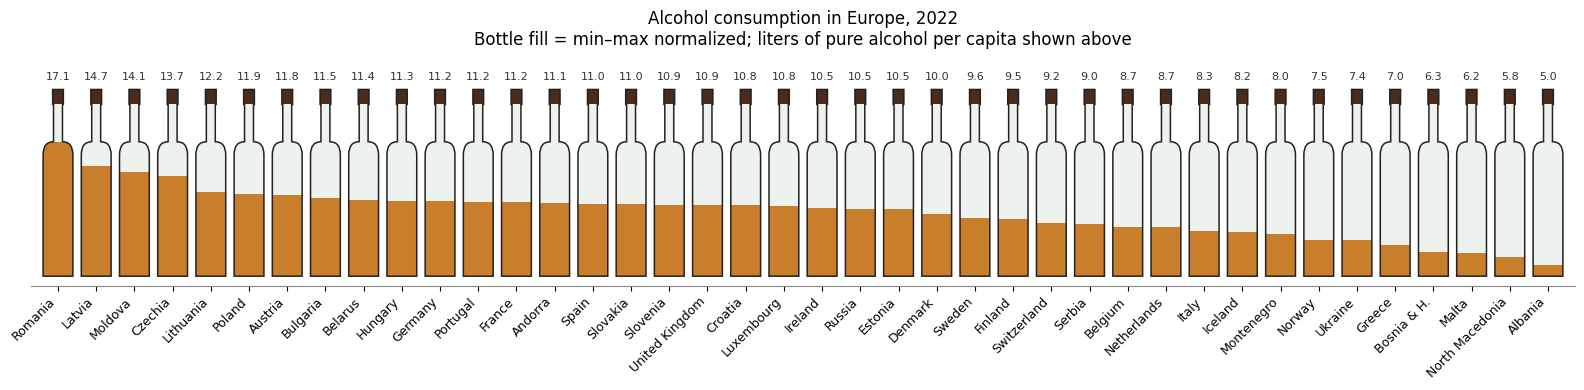

In [19]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Rectangle

def bottle_path(x_center, y_base, width, height):
    w  = width * 0.50
    nw = width * 0.15
    cw = width * 0.18
    Hb, Hs, Hn, Hc = height * 0.65, height * 0.72, height * 0.92, height * 1.00
    verts = [
        (x_center - w,  y_base), (x_center + w,  y_base),
        (x_center + w,  y_base + Hb),
        (x_center + w,  y_base + Hs), (x_center + nw, y_base + Hs),
        (x_center + nw, y_base + Hn), (x_center + cw, y_base + Hn),
        (x_center + cw, y_base + Hc), (x_center - cw, y_base + Hc),
        (x_center - cw, y_base + Hn), (x_center - nw, y_base + Hn),
        (x_center - nw, y_base + Hs),
        (x_center - w,  y_base + Hs), (x_center - w,  y_base + Hb),
        (x_center - w,  y_base),
    ]
    codes = [
        Path.MOVETO, Path.LINETO, Path.LINETO,
        Path.CURVE3, Path.CURVE3,
        Path.LINETO, Path.LINETO, Path.LINETO,
        Path.LINETO, Path.LINETO, Path.LINETO, Path.LINETO,
        Path.CURVE3, Path.CURVE3,
        Path.CLOSEPOLY,
    ]
    return Path(verts, codes)

# Shorten the long official names so the x-axis is readable
df_europe_2022['Country'] = df_europe_2022['Country'].replace({
    'Netherlands (Kingdom of the)': 'Netherlands',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'Republic of Moldova': 'Moldova',
    'Russian Federation': 'Russia',
    'Bosnia and Herzegovina': 'Bosnia & H.',
})

df_plot = df_europe_2022.sort_values('Liters_of_alc', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 4))

H = 1.0           # bottle height (in data units)
W = 0.78          # bottle outer width
fill_top = H * 0.72   # fill_frac = 1.0 → liquid reaches top of shoulder

for i, row in df_plot.iterrows():
    path = bottle_path(i, 0, W, H)

    # 1. Glass (light tint, full bottle silhouette)
    glass = PathPatch(path, facecolor='#eef2ee', edgecolor='none', zorder=1)
    ax.add_patch(glass)

    # 2. Liquid: a rectangle clipped to the bottle shape
    floor = 0.08   # bump this up/down to taste
    fill_y = fill_top * (floor + (1 - floor) * row['alc_normalized'])
    if fill_y > 0:
        liquid = Rectangle((i - W/2, 0), W, fill_y,
                           facecolor='#c97e2c', edgecolor='none', zorder=2)
        ax.add_patch(liquid)
        liquid.set_clip_path(glass)         # <-- the key line

    # 3. Cap
    cap_w = W * 0.36
    cap = Rectangle((i - cap_w/2, H*0.92), cap_w, H*0.08,
                    facecolor='#4a2c1a', edgecolor='none', zorder=3)
    ax.add_patch(cap)

    # 4. Outline on top
    outline = PathPatch(path, facecolor='none', edgecolor='#222',
                        linewidth=1.1, zorder=4)
    ax.add_patch(outline)

    # Liters label above each bottle
    ax.text(i, H * 1.04, f"{row['Liters_of_alc']:.1f}",
            ha='center', va='bottom', fontsize=8, color='#333')

ax.set_xlim(-0.7, len(df_plot) - 0.3)
ax.set_ylim(-0.05, H * 1.15)
ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot['Country'], rotation=45, ha='right', fontsize=9)
ax.set_yticks([])
ax.set_title('Alcohol consumption in Europe, 2022\n'
             'Bottle fill = min–max normalized; liters of pure alcohol per capita shown above',
             fontsize=12, pad=12)

for s in ['top', 'right', 'left']:
    ax.spines[s].set_visible(False)
ax.spines['bottom'].set_color('#888')

plt.tight_layout()
fig.savefig(r'C:\Users\ThinkPad\Desktop\Mastermind\WHO_health_indicators\Plot_pictures\europe_alcohol_2022_barplot_Version1.png', dpi=300, bbox_inches='tight')
plt.show()

# Buliding the bottles on a map

In [20]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


Not found on map: {'MLT', 'AND'}


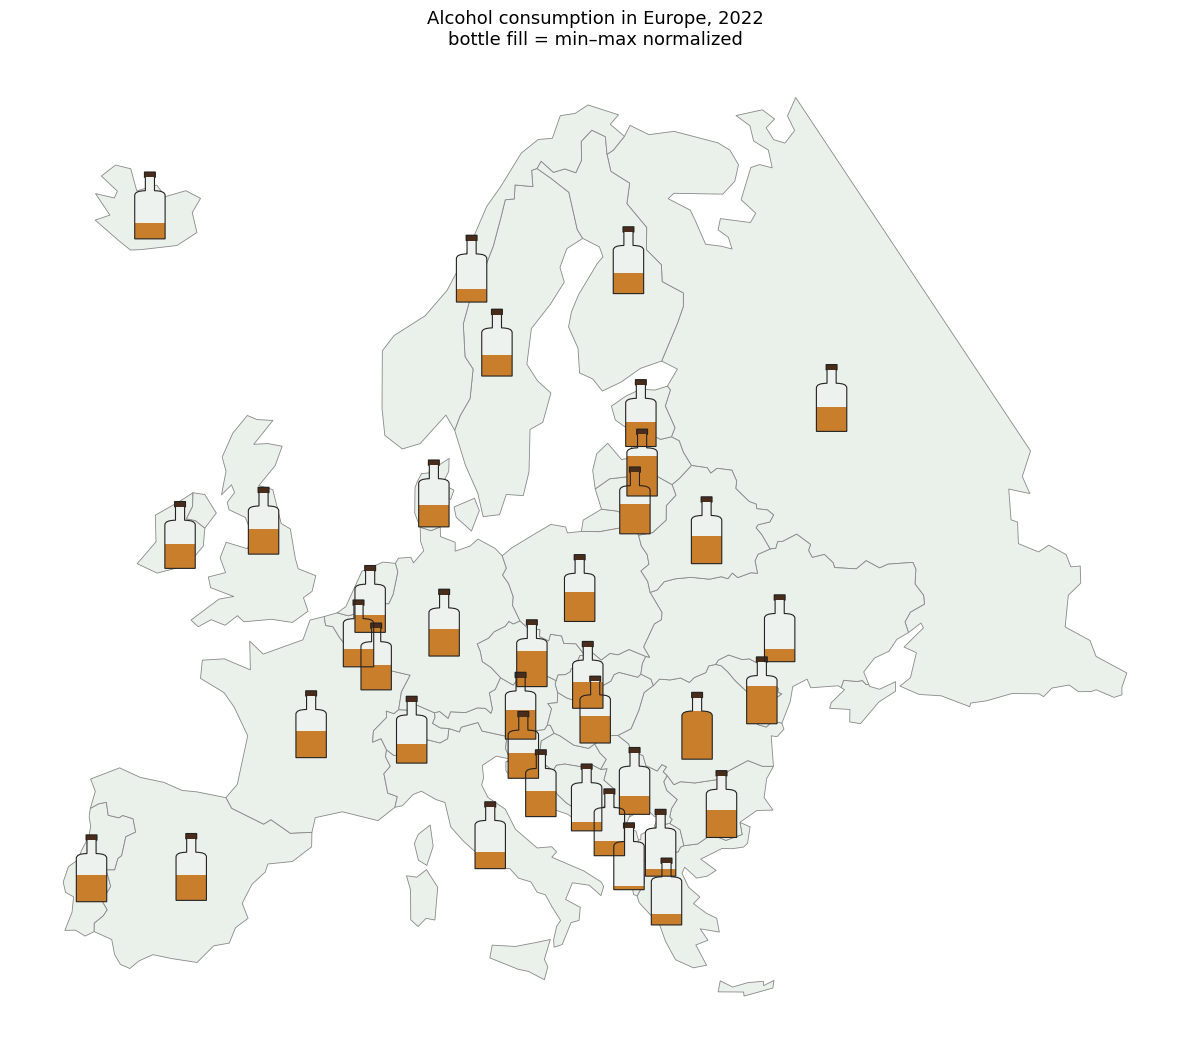

In [26]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Rectangle
from shapely.geometry import box

# 1. Load Natural Earth countries (small download, ~200 KB)
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# 2. Filter to European countries via your iso_alpha3 column
europe_iso = set(df_europe_2022['iso_alpha3'])
europe_gdf = world[world['ADM0_A3'].isin(europe_iso)].copy()

missing = europe_iso - set(europe_gdf['ADM0_A3'])
if missing:
    print('Not found on map:', missing)

# 3. Clip to Europe bbox so Russia doesn't drag the view across Asia
europe_gdf = gpd.clip(europe_gdf, box(-30, 33, 50, 73))

# 4. Reproject to ETRS89-LAEA — proper equal-area projection for Europe
europe_gdf = europe_gdf.to_crs(epsg=3035)

# 5. Merge with the alcohol data
europe_gdf = europe_gdf.merge(
    df_europe_2022[['iso_alpha3', 'Liters_of_alc', 'alc_normalized']],
    left_on='ADM0_A3', right_on='iso_alpha3'
)

# 6. Bottle path function (same as before)
def bottle_path(x_center, y_base, width, height):
    w, nw, cw = width*0.50, width*0.15, width*0.18
    Hb, Hs, Hn, Hc = height*0.65, height*0.72, height*0.92, height*1.00
    verts = [
        (x_center - w,  y_base), (x_center + w,  y_base),
        (x_center + w,  y_base + Hb),
        (x_center + w,  y_base + Hs), (x_center + nw, y_base + Hs),
        (x_center + nw, y_base + Hn), (x_center + cw, y_base + Hn),
        (x_center + cw, y_base + Hc), (x_center - cw, y_base + Hc),
        (x_center - cw, y_base + Hn), (x_center - nw, y_base + Hn),
        (x_center - nw, y_base + Hs),
        (x_center - w,  y_base + Hs), (x_center - w,  y_base + Hb),
        (x_center - w,  y_base),
    ]
    codes = [
        Path.MOVETO, Path.LINETO, Path.LINETO,
        Path.CURVE3, Path.CURVE3,
        Path.LINETO, Path.LINETO, Path.LINETO,
        Path.LINETO, Path.LINETO, Path.LINETO, Path.LINETO,
        Path.CURVE3, Path.CURVE3,
        Path.CLOSEPOLY,
    ]
    return Path(verts, codes)

# 7. Plot map + bottles
fig, ax = plt.subplots(figsize=(12, 13))
europe_gdf.plot(ax=ax, color='#eaf0ea', edgecolor='#888', linewidth=0.6)

# Scale the bottles to the map's coordinate system
xmin, ymin, xmax, ymax = europe_gdf.total_bounds
W = (xmax - xmin) / 35      # bottle width — tweak this if too big/small
H = W * 2.2                  # bottle height
fill_top = H * 0.72
floor = 0.08

for _, row in europe_gdf.iterrows():
    pt = row.geometry.representative_point()    # guaranteed inside polygon
    cx, cy = pt.x, pt.y
    y_base = cy - H / 2                          # center bottle on point

    path = bottle_path(cx, y_base, W, H)

    glass = PathPatch(path, facecolor='#eef2ee', edgecolor='none', zorder=3)
    ax.add_patch(glass)

    fill_y = fill_top * (floor + (1 - floor) * row['alc_normalized'])
    liquid = Rectangle((cx - W/2, y_base), W, fill_y,
                       facecolor='#c97e2c', edgecolor='none', zorder=4)
    ax.add_patch(liquid)
    liquid.set_clip_path(glass)

    cap_w = W * 0.36
    cap = Rectangle((cx - cap_w/2, y_base + H*0.92), cap_w, H*0.08,
                    facecolor='#4a2c1a', edgecolor='none', zorder=5)
    ax.add_patch(cap)

    outline = PathPatch(path, facecolor='none', edgecolor='#222',
                        linewidth=0.8, zorder=6)
    ax.add_patch(outline)

ax.set_axis_off()
ax.set_title('Alcohol consumption in Europe, 2022\nbottle fill = min–max normalized',
             fontsize=13)
plt.tight_layout()
fig.savefig(r'C:\Users\ThinkPad\Desktop\Mastermind\WHO_health_indicators\Plot_pictures\Alcohol_consumption_europe_map_2022.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
pip install mplcursors ipympl

Note: you may need to restart the kernel to use updated packages.


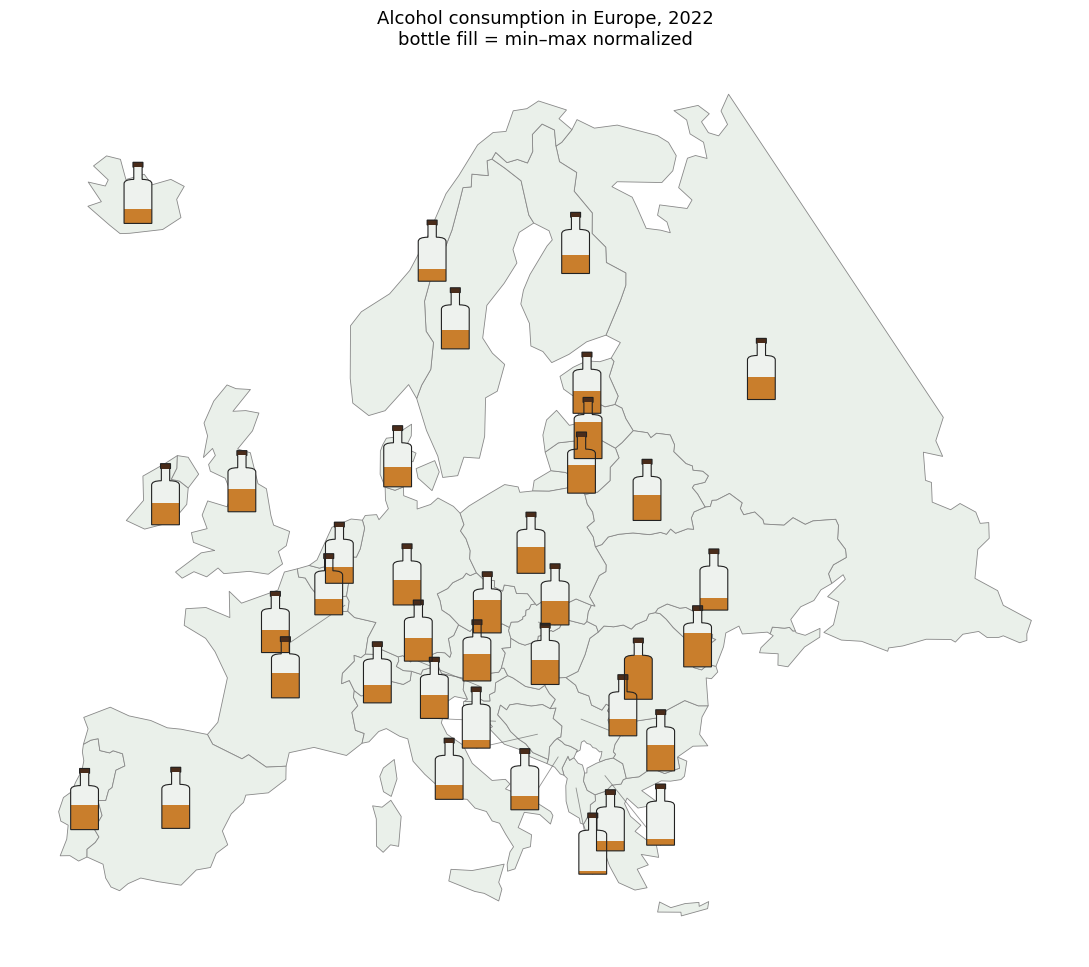

In [23]:
import geopandas as gpd
import matplotlib.pyplot as plt
import mplcursors
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Rectangle
from shapely.geometry import box

# 1. Load Natural Earth countries
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# 2. Filter to European countries via your iso_alpha3 column
europe_iso = set(df_europe_2022['iso_alpha3'])
europe_gdf = world[world['ADM0_A3'].isin(europe_iso)].copy()

# 3. Clip Russia (and others) to a Europe-focused bbox
europe_gdf = gpd.clip(europe_gdf, box(-30, 33, 50, 73))

# 4. Reproject to ETRS89-LAEA, the standard equal-area projection for Europe
europe_gdf = europe_gdf.to_crs(epsg=3035)

# 5. Merge with the alcohol data
europe_gdf = europe_gdf.merge(
    df_europe_2022[['iso_alpha3', 'Country', 'Liters_of_alc', 'alc_normalized']],
    left_on='ADM0_A3', right_on='iso_alpha3'
)

# 6. Bottle path
def bottle_path(x_center, y_base, width, height):
    w, nw, cw = width*0.50, width*0.15, width*0.18
    Hb, Hs, Hn, Hc = height*0.65, height*0.72, height*0.92, height*1.00
    verts = [
        (x_center - w,  y_base), (x_center + w,  y_base),
        (x_center + w,  y_base + Hb),
        (x_center + w,  y_base + Hs), (x_center + nw, y_base + Hs),
        (x_center + nw, y_base + Hn), (x_center + cw, y_base + Hn),
        (x_center + cw, y_base + Hc), (x_center - cw, y_base + Hc),
        (x_center - cw, y_base + Hn), (x_center - nw, y_base + Hn),
        (x_center - nw, y_base + Hs),
        (x_center - w,  y_base + Hs), (x_center - w,  y_base + Hb),
        (x_center - w,  y_base),
    ]
    codes = [
        Path.MOVETO, Path.LINETO, Path.LINETO,
        Path.CURVE3, Path.CURVE3,
        Path.LINETO, Path.LINETO, Path.LINETO,
        Path.LINETO, Path.LINETO, Path.LINETO, Path.LINETO,
        Path.CURVE3, Path.CURVE3,
        Path.CLOSEPOLY,
    ]
    return Path(verts, codes)

# 7. Plot
fig, ax = plt.subplots(figsize=(11, 12))
europe_gdf.plot(ax=ax, color='#eaf0ea', edgecolor='#888', linewidth=0.6)

xmin, ymin, xmax, ymax = europe_gdf.total_bounds
W = (xmax - xmin) / 35
H = W * 2.2
fill_top = H * 0.72
floor = 0.08

# Manual offsets for crowded countries (in units of bottle widths W)
offsets = {
    'ALB': ( 0.6, -2.0),
    'MKD': ( 2.0, -1.4),
    'MNE': (-1.2, -0.8),
    'BIH': (-2.2,  0.6),
    'SRB': ( 1.5,  0.5),
    'HRV': (-2.2,  1.2),
    'SVN': (-2.2,  2.0),
    'SVK': ( 0.6,  1.0),
    'LUX': (-2.5, -0.6),
    'MLT': ( 0.0, -2.5),
}

bottle_artists = []

for _, row in europe_gdf.iterrows():
    pt = row.geometry.representative_point()
    cx, cy = pt.x, pt.y

    dx, dy = offsets.get(row['ADM0_A3'], (0, 0))
    bx = cx + dx * W
    by = cy + dy * W
    y_base = by - H / 2

    if (dx, dy) != (0, 0):
        ax.plot([cx, bx], [cy, y_base],
                color='#666', linewidth=0.6, alpha=0.7, zorder=2)

    path = bottle_path(bx, y_base, W, H)

    glass = PathPatch(path, facecolor='#eef2ee', edgecolor='none', zorder=3)
    ax.add_patch(glass)

    fill_y = fill_top * (floor + (1 - floor) * row['alc_normalized'])
    liquid = Rectangle((bx - W/2, y_base), W, fill_y,
                       facecolor='#c97e2c', edgecolor='none', zorder=4)
    ax.add_patch(liquid)
    liquid.set_clip_path(glass)

    cap_w = W * 0.36
    cap = Rectangle((bx - cap_w/2, y_base + H*0.92), cap_w, H*0.08,
                    facecolor='#4a2c1a', edgecolor='none', zorder=5)
    ax.add_patch(cap)

    outline = PathPatch(
        path, facecolor='none', edgecolor='#222',
        linewidth=0.8, zorder=6,
        label=f"{row['Country']}\n{row['Liters_of_alc']:.1f} L per capita",
    )
    ax.add_patch(outline)
    bottle_artists.append(outline)

ax.set_axis_off()
ax.set_title('Alcohol consumption in Europe, 2022\nbottle fill = min–max normalized',
             fontsize=13)

# Hover tooltip
cursor = mplcursors.cursor(bottle_artists, hover=True)
@cursor.connect("add")
def _(sel):
    sel.annotation.set_text(sel.artist.get_label())
    sel.annotation.get_bbox_patch().set(fc='white', alpha=0.95)

plt.tight_layout()
fig.savefig(r'C:\Users\ThinkPad\Desktop\Mastermind\WHO_health_indicators\Plot_pictures\Alcohol_consumption_europe_map_2022_smallCountries.png', dpi=300, bbox_inches='tight')
plt.show()

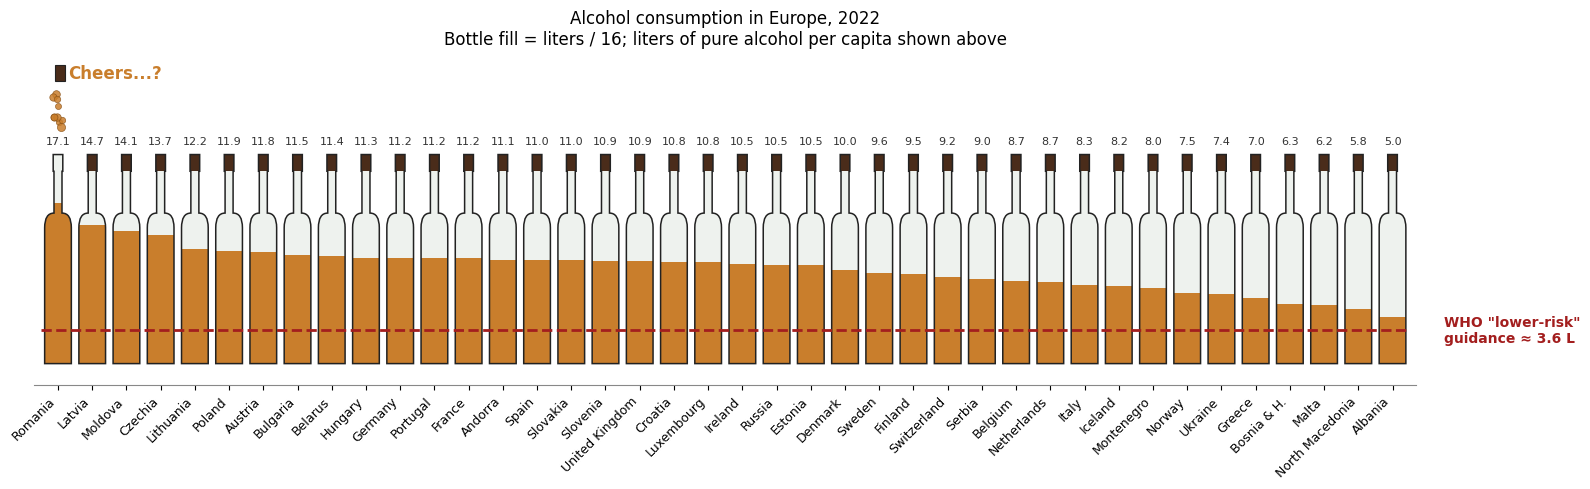

In [24]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Rectangle
import numpy as np

def bottle_path(x_center, y_base, width, height):
    w  = width * 0.50
    nw = width * 0.15
    cw = width * 0.18
    Hb, Hs, Hn, Hc = height * 0.65, height * 0.72, height * 0.92, height * 1.00
    verts = [
        (x_center - w,  y_base), (x_center + w,  y_base),
        (x_center + w,  y_base + Hb),
        (x_center + w,  y_base + Hs), (x_center + nw, y_base + Hs),
        (x_center + nw, y_base + Hn), (x_center + cw, y_base + Hn),
        (x_center + cw, y_base + Hc), (x_center - cw, y_base + Hc),
        (x_center - cw, y_base + Hn), (x_center - nw, y_base + Hn),
        (x_center - nw, y_base + Hs),
        (x_center - w,  y_base + Hs), (x_center - w,  y_base + Hb),
        (x_center - w,  y_base),
    ]
    codes = [
        Path.MOVETO, Path.LINETO, Path.LINETO,
        Path.CURVE3, Path.CURVE3,
        Path.LINETO, Path.LINETO, Path.LINETO,
        Path.LINETO, Path.LINETO, Path.LINETO, Path.LINETO,
        Path.CURVE3, Path.CURVE3,
        Path.CLOSEPOLY,
    ]
    return Path(verts, codes)

df_europe_2022['Country'] = df_europe_2022['Country'].replace({
    'Netherlands (Kingdom of the)': 'Netherlands',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'Republic of Moldova': 'Moldova',
    'Russian Federation': 'Russia',
    'Bosnia and Herzegovina': 'Bosnia & H.',
})

df_plot = df_europe_2022.sort_values('Liters_of_alc', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 5))

H = 1.0
W = 0.78
fill_top = H * 0.72
REFERENCE_MAX = 16.0       # bottle fill scales as liters / REFERENCE_MAX

# ============ Bottles ============
for i, row in df_plot.iterrows():
    path = bottle_path(i, 0, W, H)

    glass = PathPatch(path, facecolor='#eef2ee', edgecolor='none', zorder=1)
    ax.add_patch(glass)

    fill_y = fill_top * (row['Liters_of_alc'] / REFERENCE_MAX)
    if fill_y > 0:
        liquid = Rectangle((i - W/2, 0), W, fill_y,
                           facecolor='#c97e2c', edgecolor='none', zorder=2)
        ax.add_patch(liquid)
        liquid.set_clip_path(glass)

    # Cap — skip for fullest bottle (it flies off)
    if i != 0:
        cap_w = W * 0.36
        cap = Rectangle((i - cap_w/2, H*0.92), cap_w, H*0.08,
                        facecolor='#4a2c1a', edgecolor='none', zorder=3)
        ax.add_patch(cap)

    outline = PathPatch(path, facecolor='none', edgecolor='#222',
                        linewidth=1.1, zorder=4)
    ax.add_patch(outline)

    ax.text(i, H * 1.04, f"{row['Liters_of_alc']:.1f}",
            ha='center', va='bottom', fontsize=8, color='#333')

# ============ Flying cap + droplets on bottle 0 ============
cap_w = W * 0.36
cap_h = H * 0.08
cap_fly_y = 1.35                                # ← higher up

ax.add_patch(Rectangle((-cap_w/2 + 0.05, cap_fly_y),
                       cap_w, cap_h,
                       facecolor='#4a2c1a', edgecolor='#222',
                       linewidth=0.8, zorder=5))

# Cheers! text
ax.text(0.30, cap_fly_y + cap_h/2, 'Cheers...?',
        ha='left', va='center', fontsize=12, fontweight='bold',
        color='#c97e2c',  zorder=6)

# Droplets between bottle top and the flying cap
np.random.seed(42)
for _ in range(10):
    dx = np.random.uniform(-0.18, 0.18)
    dy = np.random.uniform(1.13, 1.3)
    ds = np.random.uniform(18, 35)
    ax.scatter(dx, dy, s=ds, marker='o', color='#c97e2c',
               alpha=0.85, edgecolor='#8a5318', linewidth=0.5, zorder=4)

# ============ WHO line + label off to the right ============
threshold_liters = 3.6
fill_threshold_y = fill_top * (threshold_liters / REFERENCE_MAX)

# Line stops at the last bottle
ax.plot([-0.5, len(df_plot) - 0.5],
        [fill_threshold_y, fill_threshold_y],
        linestyle='--', linewidth=2.0,
        color='#a31e1e', alpha=1.0, zorder=5)

# Label sits to the right of the last bottle, aligned with the line
ax.text(len(df_plot) + 0.5, fill_threshold_y,
        f'WHO "lower-risk"\nguidance ≈ {threshold_liters} L',
        ha='left', va='center',
        fontsize=10, fontweight='bold',
        color='#a31e1e', zorder=5)

# ============ Axes ============
ax.set_xlim(-0.7, len(df_plot) - 0.3)
ax.set_ylim(-0.1, 1.45)
ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot['Country'], rotation=45, ha='right', fontsize=9)
ax.set_yticks([])
ax.set_title('Alcohol consumption in Europe, 2022\n'
             'Bottle fill = liters / 16; liters of pure alcohol per capita shown above',
             fontsize=12, pad=12)
for s in ['top', 'right', 'left']:
    ax.spines[s].set_visible(False)
ax.spines['bottom'].set_color('#888')

plt.tight_layout()
fig.savefig(r'C:\Users\ThinkPad\Desktop\Mastermind\WHO_health_indicators\Plot_pictures\europe_alcohol_2022_barplot_fun.png',
            dpi=300, bbox_inches='tight')
plt.show()